# Home task: supervised (titanic)

### Import libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier

%matplotlib inline

### Load the dataset

In [39]:
# Переконайся, що папка titanic і файли існують, або вкажи просто 'train.csv', якщо вони в одній папці
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("train shape =", train.shape)
print("test shape  =", test.shape)
train.head()

train shape = (891, 12)
test shape  = (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### review of the data

In [40]:
print(train.info())
print()
print(test.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null   

### Basic statistics

In [41]:
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### Data overview

In [42]:
print("Survival rate:")
print(train['Survived'].value_counts(normalize=True))
print()

print("Survival by sex:")
print(pd.crosstab(train['Sex'], train['Survived'], normalize='index'))
print()

print("Survival by passenger class:")
print(pd.crosstab(train['Pclass'], train['Survived'], normalize='index'))

Survival rate:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Survival by sex:
Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908

Survival by passenger class:
Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


### Visual check

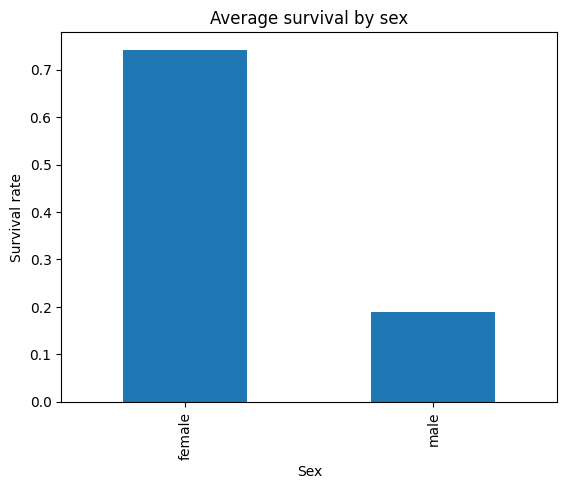

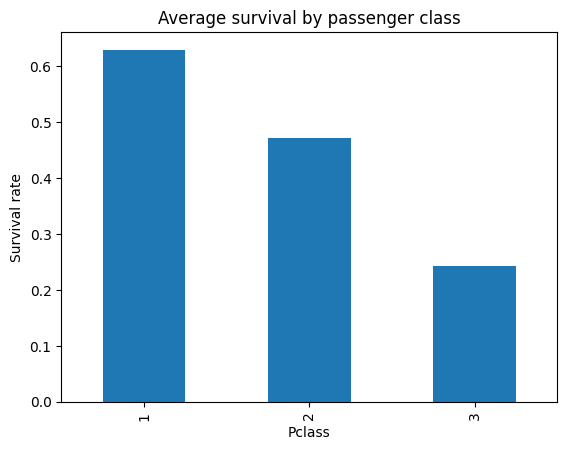

In [43]:
train.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Average survival by sex')
plt.ylabel('Survival rate')
plt.show()

train.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Average survival by passenger class')
plt.ylabel('Survival rate')
plt.show()

### Feature engineering

In [44]:
def add_features(df):
    df = df.copy()

    # family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # title from name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
        'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # deck from cabin
    df['Deck'] = df['Cabin'].str[0].fillna('Unknown')

    # simple ticket prefix
    df['TicketPrefix'] = (
        df['Ticket']
        .astype(str)
        .str.replace(r'\d+', '', regex=True)
        .str.replace(r'[./ ]', '', regex=True)
        .replace('', 'None')
    )

    return df

train_fe = add_features(train)
test_fe = add_features(test)

train_fe.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,Deck,TicketPrefix
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr,Unknown,A
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,C,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss,Unknown,STONO
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,C,None
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr,Unknown,None


### Prepare features and target

In [45]:
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
cat_cols = ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'Title', 'Deck', 'TicketPrefix']

X = train_fe.drop(columns=['Survived'] + drop_cols)
y = train_fe['Survived']
X_test_final = test_fe.drop(columns=drop_cols)

print("X shape =", X.shape)
print("X_test_final shape =", X_test_final.shape)

X shape = (891, 12)
X_test_final shape = (418, 12)


### Data cleaning

In [46]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

### Baseline check

In [47]:
baseline_pred = (train['Sex'] == 'female').astype(int)
baseline_acc = accuracy_score(y, baseline_pred)

print("Baseline accuracy = {:.3f}".format(baseline_acc))

Baseline accuracy = 0.787


### Train the model

In [48]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

train_acc = accuracy_score(y_train, train_pred)
valid_acc = accuracy_score(y_valid, valid_pred)

print("Train accuracy = {:.3f}".format(train_acc))
print("Validation accuracy = {:.3f}".format(valid_acc))
print()
print(classification_report(y_valid, valid_pred))

Train accuracy = 0.919
Validation accuracy = 0.816

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



### Cross validation

In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy = {:.3f}".format(cv_scores.mean()))
print("Std CV accuracy  = {:.3f}".format(cv_scores.std()))

CV scores: [0.8547486  0.84831461 0.82022472 0.83707865 0.85393258]
Mean CV accuracy = 0.843
Std CV accuracy  = 0.013


### Train on full train set and predict test set

In [50]:
model.fit(X, y)

test_pred = model.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_pred.astype(int)
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


### Save the submission file

In [51]:
submission.to_csv("submission.csv", index=False)
print("Submission saved to:", "submission.csv")
print("Submission shape:", submission.shape)

Submission saved to: submission.csv
Submission shape: (418, 2)


### Kaggle result
![My result](kaggle.png)